# tugas-1-unsupervised-learning

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan FIFA 24 player stats Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/rehandl23/fifa-24-player-stats-dataset

Tujuan utama dari tugas ini adalah membangun model K-means, HC, DBSCAN. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal
- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model K-MEAN
- Bangun model K-MEAN dengan K masing-masing (3,5,7)
- lakukan pengaturan hyperparameter pada K-MEAN
- Lakukan Elbow Method untuk mendapatkan nilai K paling optimal
- dari masing-masing eksperiment di atas, pilih salah satu yang terbaik untuk dibandingkan di akhir


4. Eksperimen Model HC
- Bangun model HC agglomerative dengan n_cluster (3,5,7, dan K hasil elbow Method K-MEAN sebelumnya)
- coba semua linkedage (`'ward', 'complete', 'average', 'single'`)
- Hyperparameter Tunning akan mendapatkan nilai plus
- dari masing-masing eksperiment di atas, pilih salah satu yang terbaik untuk dibandingkan di akhir


5. Eksperimen Model DBSCAN
- Bangun model DBSCAN
- Lakukan eksperiment dengan mengubah hyperparameter `metric=`
- Hyperparameter Tunning akan mendapatkan nilai plus
- dari masing-masing eksperiment di atas, pilih salah satu yang terbaik untuk dibandingkan di akhir


5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.

# 1. Persiapan Dataset & Eksplorasi Awal

## Import Library

In [307]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# 2. Preprocessing




## Baca dataset

In [308]:
df = pd.read_csv('player_stats.csv', encoding='latin1')
display(df.head())

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00


## Gunakan kolom Dengan Tipe Data Numerik Saja

In [309]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

In [310]:
df = df.drop('marking', axis=1)

In [311]:
non_int_col = df.select_dtypes(include='object')
display(non_int_col.head())

,player,country,club,value
0,Cristian Castro Devenish,Colombia,Atl. Nacional,$1.400.000
1,Silaldo Taffarel,Brazil,Corinthians,$975.00
2,Thomas DÃ¤hne,Germany,Holstein Kiel,$1.100.000
3,Michael Sollbauer,Austria,SK Rapid Wien,$650.00
4,Diego Segovia,Uruguay,Independiente,$300.00


In [312]:
df = df.drop(['player', 'country', 'club'], axis=1)
df['value'] = df['value'].astype(str).str.replace(r'[$ .]', '', regex=True).astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 37 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   height          5682 non-null   int64  
 1   weight          5682 non-null   int64  
 2   age             5682 non-null   int64  
 3   ball_control    5682 non-null   int64  
 4   dribbling       5682 non-null   int64  
 5   slide_tackle    5682 non-null   int64  
 6   stand_tackle    5682 non-null   int64  
 7   aggression      5682 non-null   int64  
 8   reactions       5682 non-null   int64  
 9   att_position    5682 non-null   int64  
 10  interceptions   5682 non-null   int64  
 11  vision          5682 non-null   int64  
 12  composure       5682 non-null   int64  
 13  crossing        5682 non-null   int64  
 14  short_pass      5682 non-null   int64  
 15  long_pass       5682 non-null   int64  
 16  acceleration    5682 non-null   int64  
 17  stamina         5682 non-null   i

## Cek Apabila Terdapat Data yang Terduplikat

In [313]:
print(f"Jumlah baris sebelum menghapus duplikat: {df.shape[0]}")

print("Duplicate row:")
duplicate = df[df.duplicated(keep=False)]
display(duplicate)

df_clean = df.drop_duplicates()
print(f"Jumlah baris setelah menghapus duplikat: {df_clean.shape[0]}")

Jumlah baris sebelum menghapus duplikat: 5682
Duplicate row:


,height,weight,age,ball_control,dribbling,slide_tackle,stand_tackle,aggression,reactions,att_position,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
154,180,88,29,45,19,17,17,34,78,7,...,16,14,23,19,70,72,70,70,75,2200000.0
156,190,84,32,55,45,64,70,69,54,38,...,33,31,42,40,14,13,7,10,12,70000.0
157,181,78,24,55,53,57,60,61,58,45,...,34,25,32,28,8,13,9,7,8,35000.0
158,180,88,29,45,19,17,17,34,78,7,...,16,14,23,19,70,72,70,70,75,2200000.0
159,190,84,32,55,45,64,70,69,54,38,...,33,31,42,40,14,13,7,10,12,70000.0
160,181,78,24,55,53,57,60,61,58,45,...,34,25,32,28,8,13,9,7,8,35000.0
916,174,69,31,86,88,38,42,75,91,90,...,77,64,75,75,7,10,10,15,14,101000000.0
5229,182,73,24,91,93,32,34,64,93,92,...,80,69,84,83,11,13,5,7,6,153500000.0
5675,182,73,24,91,93,32,34,64,93,92,...,80,69,84,83,11,13,5,7,6,153500000.0
5678,174,69,31,86,88,38,42,75,91,90,...,77,64,75,75,7,10,10,15,14,101000000.0


Jumlah baris setelah menghapus duplikat: 5677


## Deteksi Data Outlier Menggunakan Box Plot

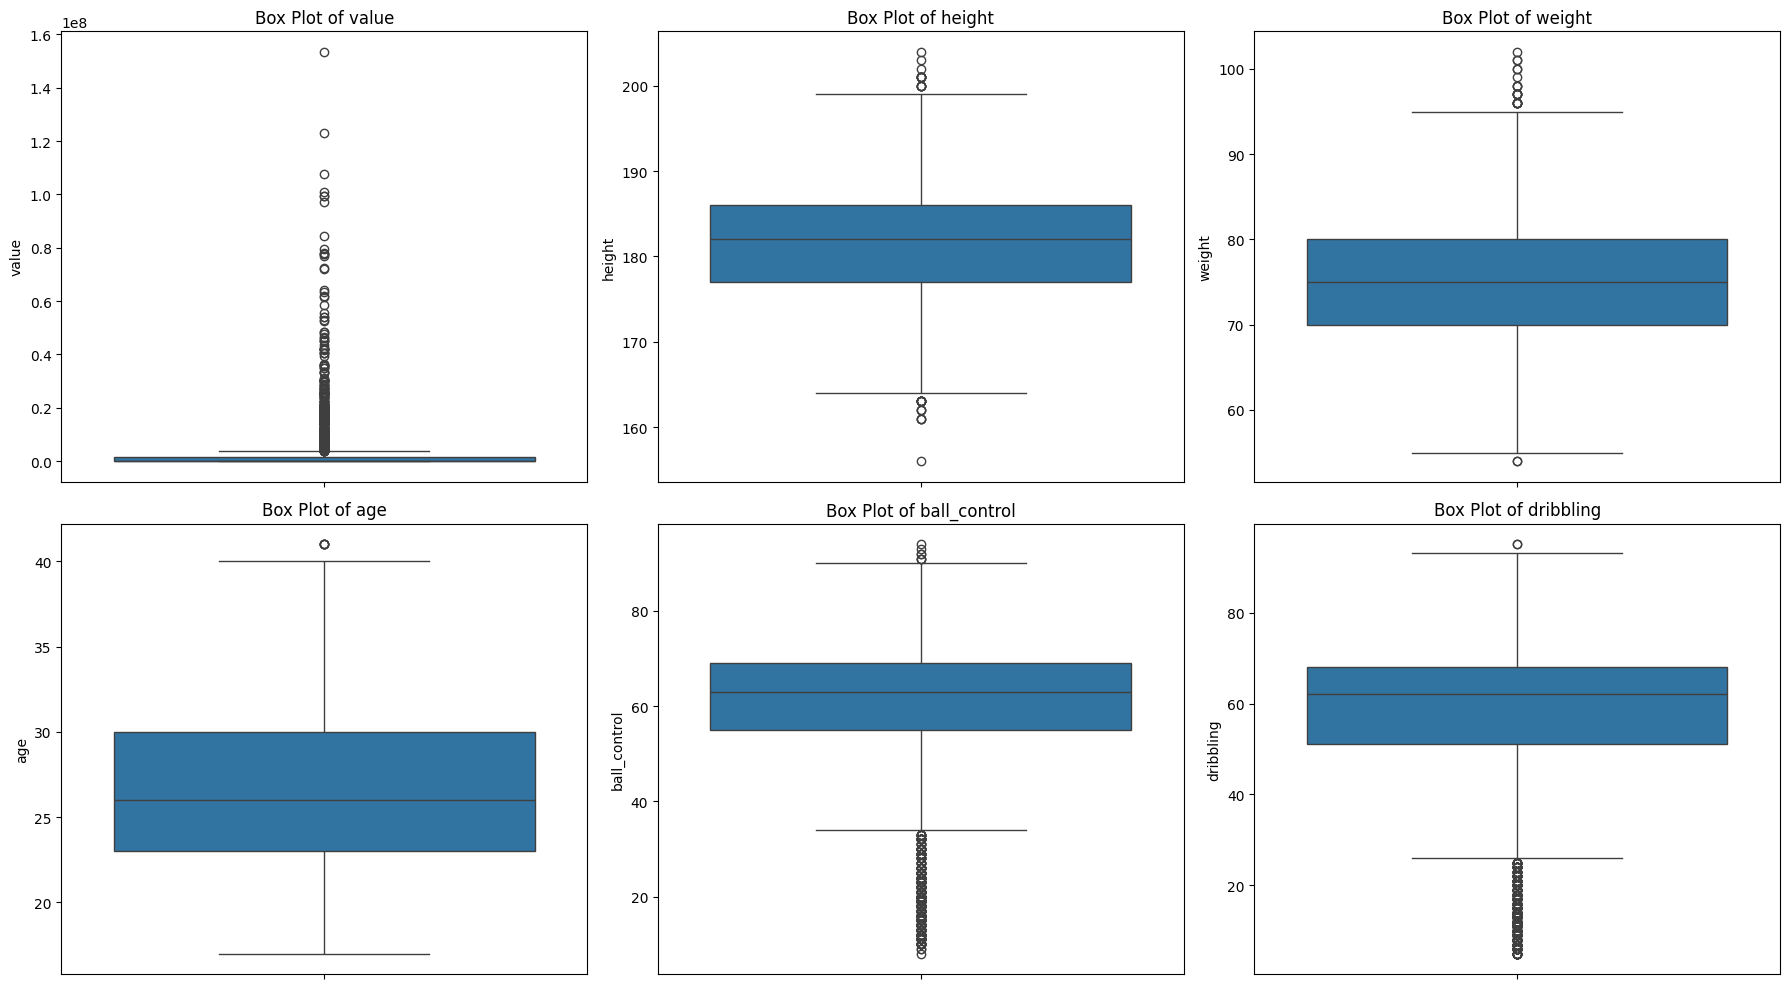

In [314]:
outlier_columns = ['value', 'height', 'weight', 'age', 'ball_control', 'dribbling']

plt.figure(figsize=(18, 10))
for i, col in enumerate(outlier_columns):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_clean[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    
plt.tight_layout()
plt.show()

## Heatmap Hubungan Antar Kolom

<Axes: >

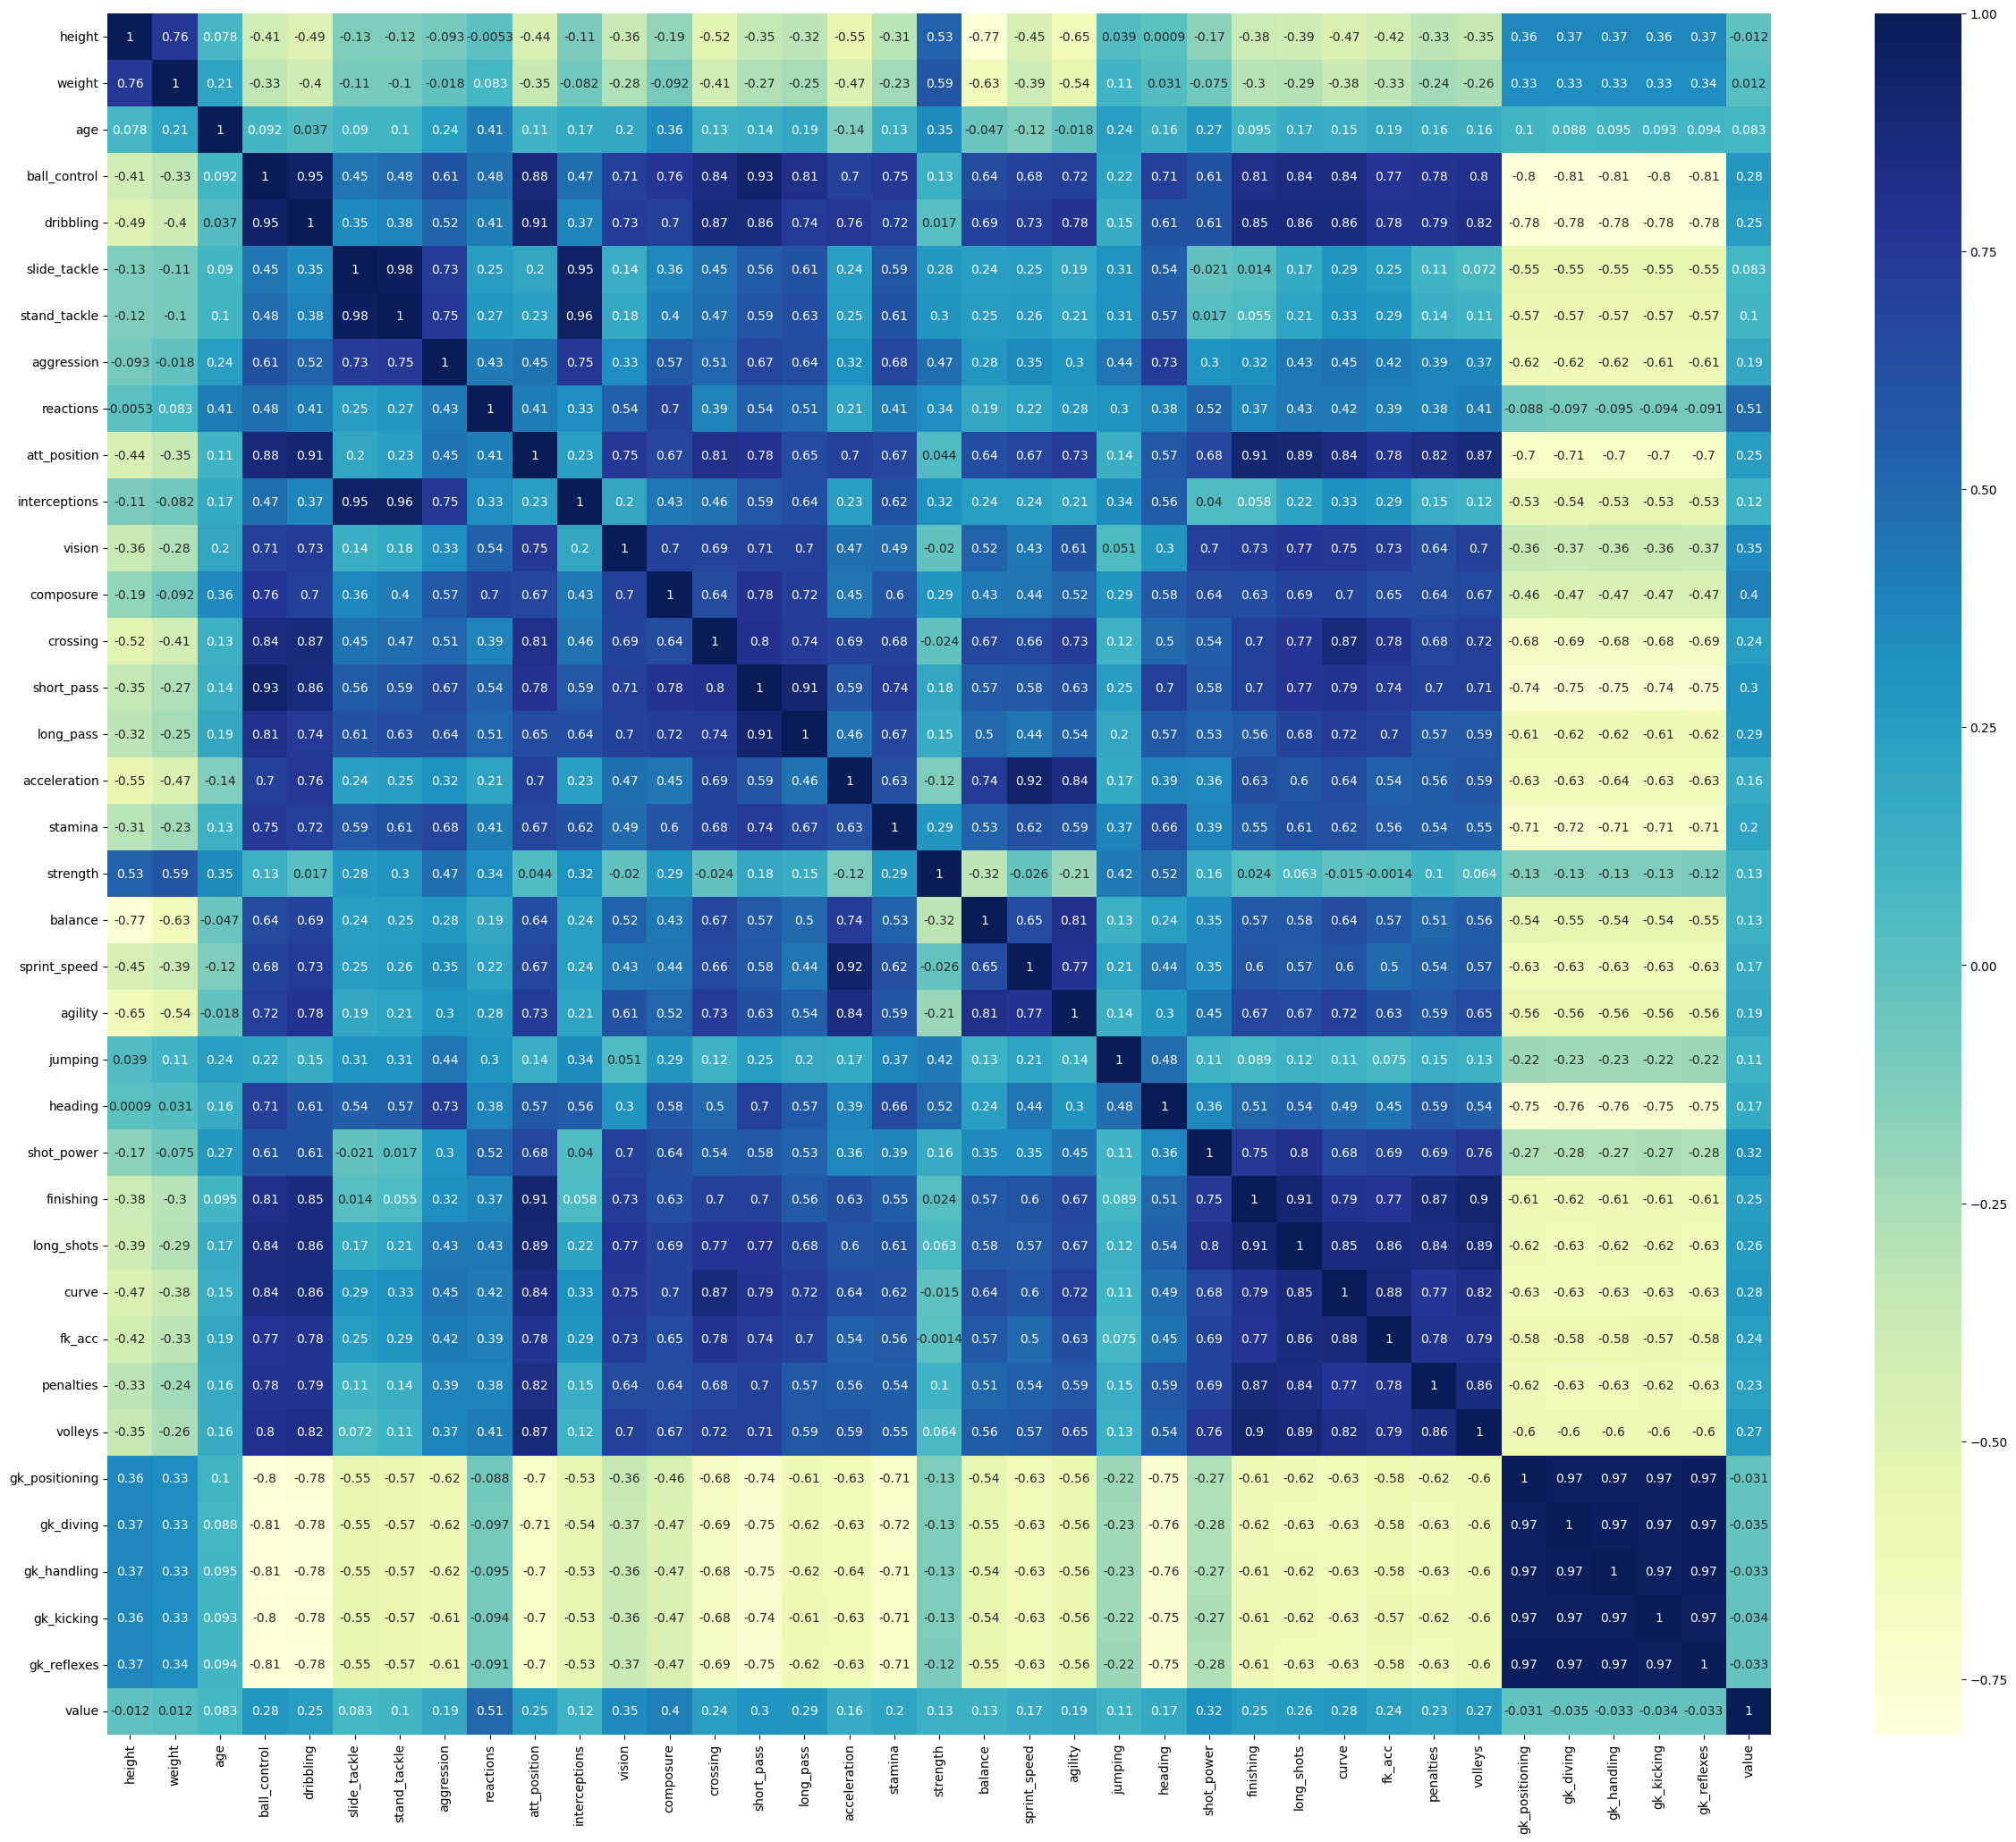

In [315]:
plt.figure(figsize=(30, 25))
sns.heatmap(df_clean.corr(), cmap="YlGnBu", annot=True)

## Reduksi Menggunakan PCA

In [316]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])
print("PCA explained variance ratio:\n", " ".join(map("{:.3f}".format, pca.explained_variance_ratio_)))

PCA explained variance ratio:
 0.500 0.500


## Gunakan Scaler Untuk Handle Outlier Ekstrem

In [317]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pca)
df_scaled = pd.DataFrame(df_scaled, columns=df_pca.columns)

display(df_scaled.head())

,PC1,PC2
0,-0.828247,1.826930
1,0.406339,0.613024
2,-2.139614,-0.975137
3,-0.843371,2.177926
4,-2.584822,-1.103807


# 3. Eksperimen Model K-MEANS


## Fit model untuk n_cluster = 3, 5, dan 7

In [318]:
df_kmeans = df_scaled.copy()

In [319]:
wcss = []
scores = []
for i in range(2, 12):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(df_kmeans)
    wcss.append(km.inertia_)

    labels = km.labels_
    silhouette_avg = silhouette_score(df_kmeans, labels)
    scores.append(silhouette_avg)
    print('wcss score for n_cluster = ' + str(i) + ' is ' + str(wcss))
    print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))

wcss score for n_cluster = 2 is [6760.437454579867]
silhoutte score for n_clusters = 2 is 0.5717338920492842
wcss score for n_cluster = 3 is [6760.437454579867, 2945.6258345360625]
silhoutte score for n_clusters = 3 is 0.5049126514172713
wcss score for n_cluster = 4 is [6760.437454579867, 2945.6258345360625, 1861.904676756452]
silhoutte score for n_clusters = 4 is 0.4657984984444149
wcss score for n_cluster = 5 is [6760.437454579867, 2945.6258345360625, 1861.904676756452, 1529.560460498838]
silhoutte score for n_clusters = 5 is 0.40228499574893756
wcss score for n_cluster = 6 is [6760.437454579867, 2945.6258345360625, 1861.904676756452, 1529.560460498838, 1295.6159369868008]
silhoutte score for n_clusters = 6 is 0.40239905082911537
wcss score for n_cluster = 7 is [6760.437454579867, 2945.6258345360625, 1861.904676756452, 1529.560460498838, 1295.6159369868008, 1124.9211201046937]
silhoutte score for n_clusters = 7 is 0.3898758904574596
wcss score for n_cluster = 8 is [6760.437454579867,

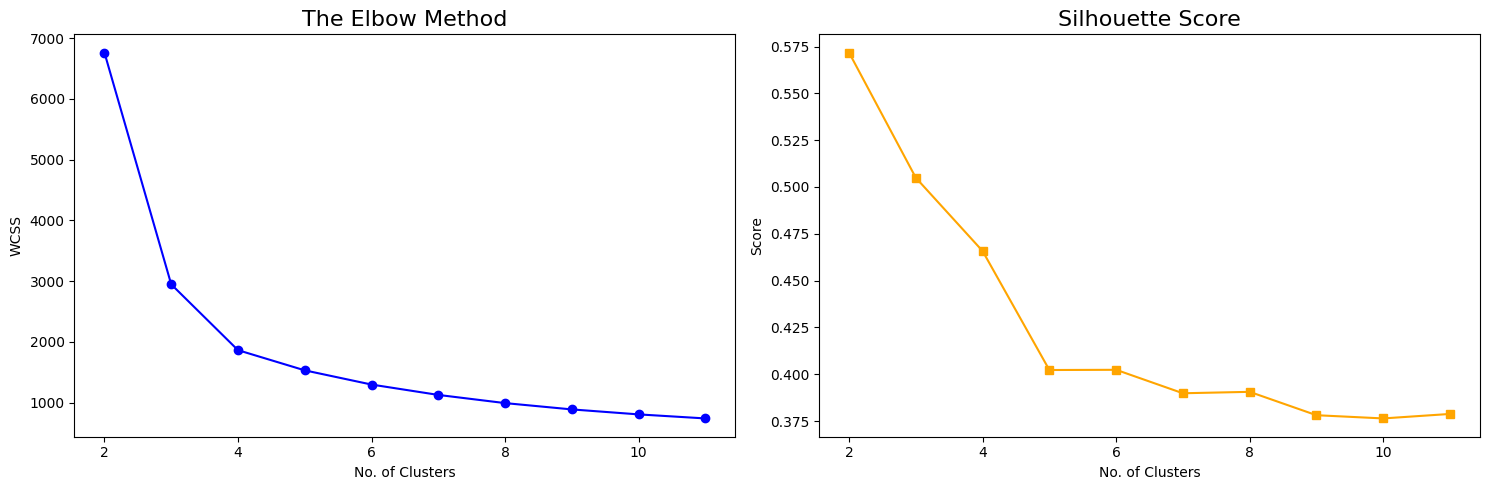

In [320]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Grafik 1: WCSS (Elbow Method)
axes[0].plot(range(2, 12), wcss, marker='o', color='blue')
axes[0].set_title('The Elbow Method', fontsize=16)
axes[0].set_xlabel('No. of Clusters')
axes[0].set_ylabel('WCSS')
# Grafik 2: Silhouette Score
axes[1].plot(range(2, 12), scores, marker='s', color='orange')
axes[1].set_title('Silhouette Score', fontsize=16)
axes[1].set_xlabel('No. of Clusters')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

In [321]:
k = 3
kmeans = KMeans(n_clusters=k, init ='k-means++', random_state=42, n_init=10)
clusters_k3 = kmeans.fit_predict(df_kmeans)

k = 5
kmeans = KMeans(n_clusters=k, init ='k-means++', random_state=42, n_init=10)
clusters_k5 = kmeans.fit_predict(df_kmeans)

k = 7
kmeans = KMeans(n_clusters=k, init ='k-means++', random_state=42, n_init=10)
clusters_k7 = kmeans.fit_predict(df_kmeans)

In [322]:
df_kmeans['cluster_k3'] = clusters_k3
df_kmeans['cluster_k5'] = clusters_k5
df_kmeans['cluster_k7'] = clusters_k7

print(f"Data setelah penambahan label klaster K-Means (cluster ditambahkan ke df_kmeans untuk visualisasi):")
display(df_kmeans.head())

Data setelah penambahan label klaster K-Means (cluster ditambahkan ke df_kmeans untuk visualisasi):


,PC1,PC2,cluster_k3,cluster_k5,cluster_k7
0,-0.828247,1.826930,1,3,2
1,0.406339,0.613024,1,1,5
2,-2.139614,-0.975137,2,2,1
3,-0.843371,2.177926,1,3,2
4,-2.584822,-1.103807,2,2,1


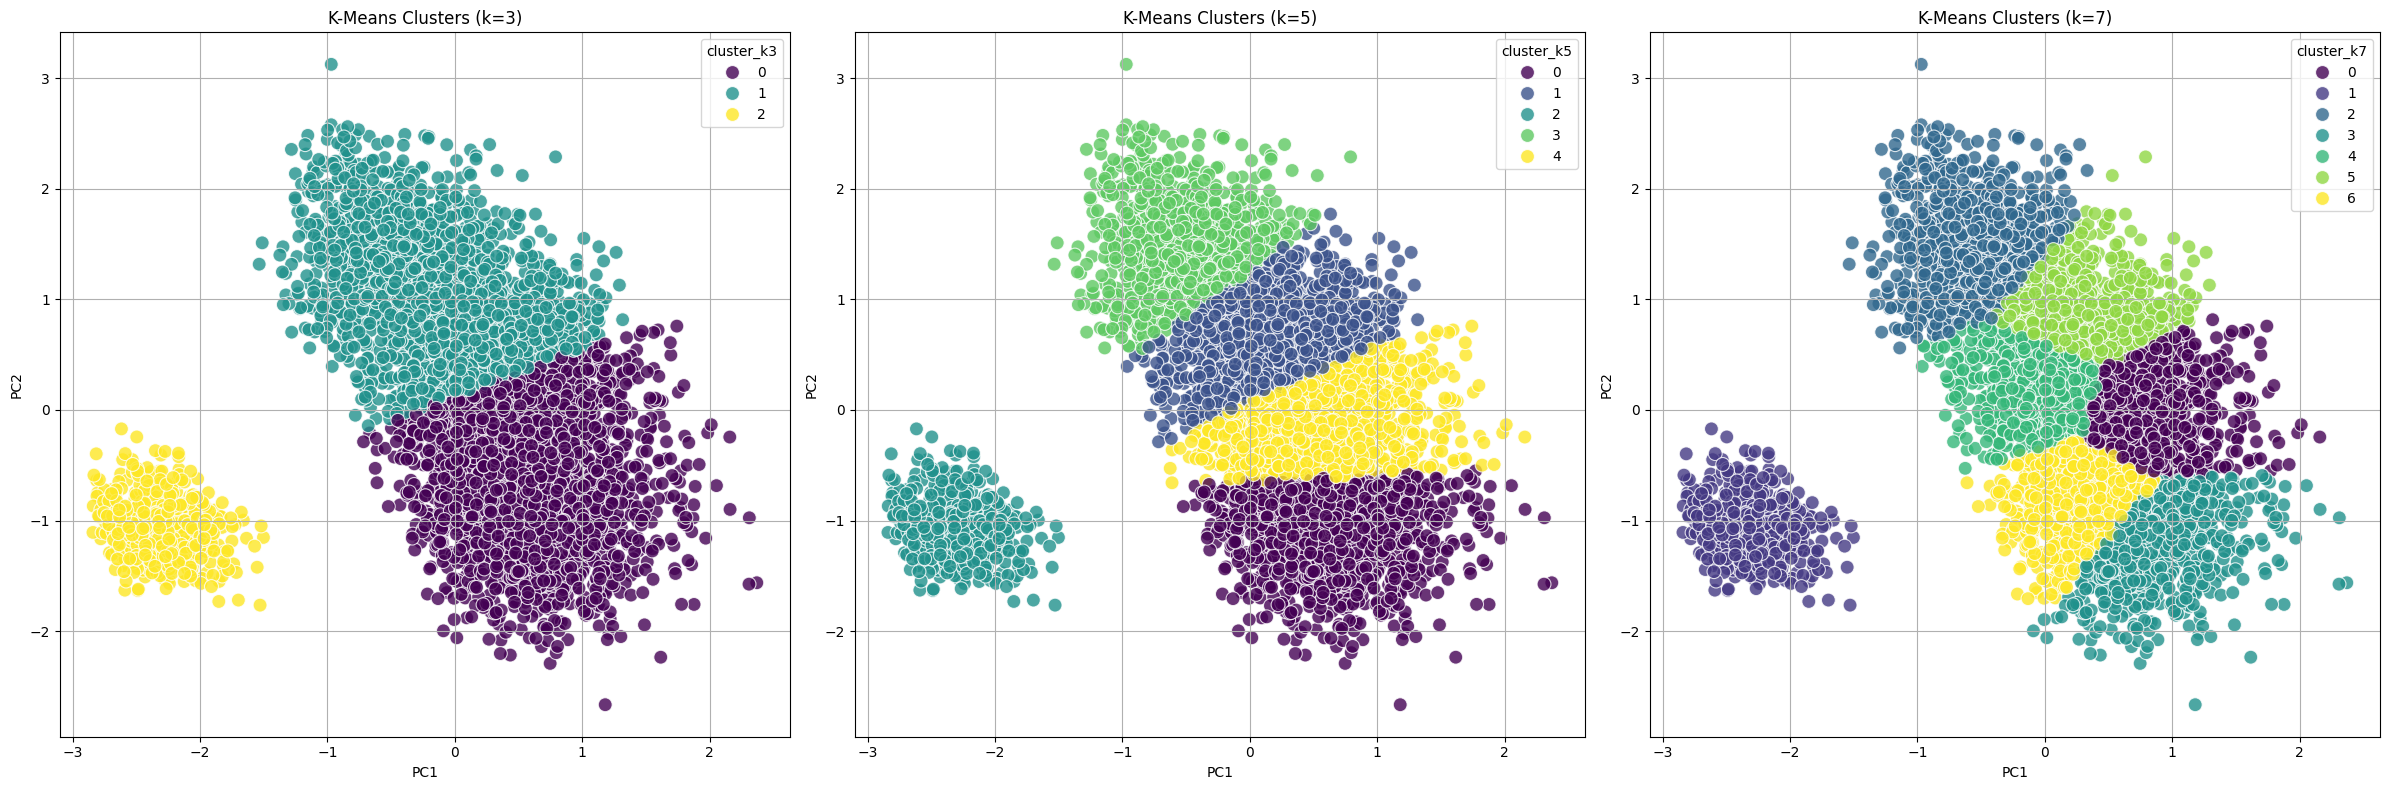

In [323]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

sns.scatterplot(x='PC1', y='PC2', hue='cluster_k3', data=df_kmeans, palette='viridis', s=100, alpha=0.8, ax=axes[0])
axes[0].set_title('K-Means Clusters (k=3)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True)

sns.scatterplot(x='PC1', y='PC2', hue='cluster_k5', data=df_kmeans, palette='viridis', s=100, alpha=0.8, ax=axes[1])
axes[1].set_title('K-Means Clusters (k=5)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(True)

sns.scatterplot(x='PC1', y='PC2', hue='cluster_k7', data=df_kmeans, palette='viridis', s=100, alpha=0.8, ax=axes[2])
axes[2].set_title('K-Means Clusters (k=7)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# 4. Eksperimen Model HC


In [324]:
df_hc = df_scaled.copy()

In [325]:
linkage_col = ['ward', 'complete', 'average', 'single']
scores_all = [[] for _ in range(len(linkage_col))]
for j in range (len(linkage_col)):
    print('Linkage: ', linkage_col[j])
    scores = []
    for i in range(2, 12):
        AC = AgglomerativeClustering(n_clusters=i, linkage = linkage_col[j]) # Menggunakan Ward Method
        AC.fit(df_hc)
        
        labels = AC.labels_
        silhouette_avg = silhouette_score(df_hc, labels)
        scores.append(silhouette_avg)
        print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))
    print("\n##########################\n")
    scores_all[j] = scores

Linkage:  ward
silhoutte score for n_clusters = 2 is 0.5717338920492842
silhoutte score for n_clusters = 3 is 0.48177757952672123
silhoutte score for n_clusters = 4 is 0.43354645510856876
silhoutte score for n_clusters = 5 is 0.3710380731142276
silhoutte score for n_clusters = 6 is 0.3501877245691264
silhoutte score for n_clusters = 7 is 0.34567259779149223
silhoutte score for n_clusters = 8 is 0.3299523411729222
silhoutte score for n_clusters = 9 is 0.3199603891731065
silhoutte score for n_clusters = 10 is 0.3285869224963282
silhoutte score for n_clusters = 11 is 0.32491102227103386

##########################

Linkage:  complete
silhoutte score for n_clusters = 2 is 0.3126398005266009
silhoutte score for n_clusters = 3 is 0.47299407024251966
silhoutte score for n_clusters = 4 is 0.3764655722178005
silhoutte score for n_clusters = 5 is 0.2831806401852183
silhoutte score for n_clusters = 6 is 0.2857513439233889
silhoutte score for n_clusters = 7 is 0.27193456566095986
silhoutte score f

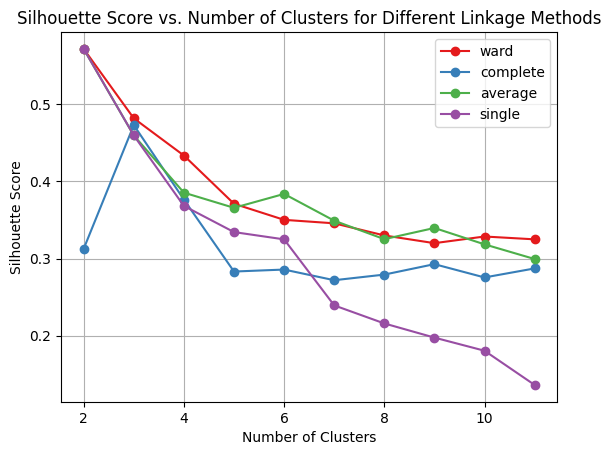

In [326]:
colors = sns.color_palette("Set1", len(linkage_col))

for j in range(len(linkage_col)):
    plt.plot(range(2, 12), scores_all[j], marker='o', color=colors[j], label=linkage_col[j])

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters for Different Linkage Methods')
plt.legend()
plt.grid(True)
plt.show()

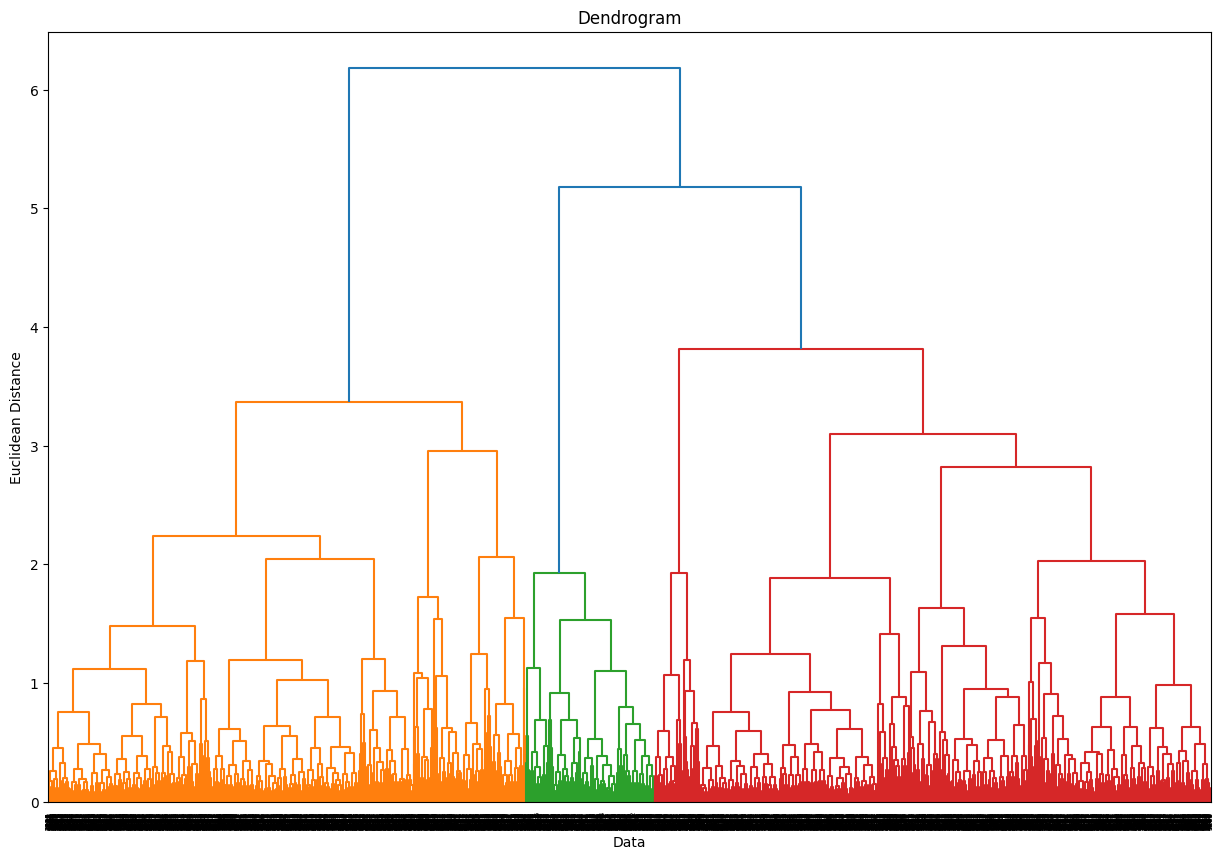

In [327]:
plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(sch.linkage(df_hc, method='complete'))
plt.title("Dendrogram")
plt.xlabel("Data")
plt.ylabel("Euclidean Distance")
plt.show()

In [328]:
hc = AgglomerativeClustering(n_clusters=3, linkage='complete')
hc_cluster = hc.fit_predict(df_hc)

df_hc['hc_cluster'] = hc_cluster

df_hc.head()

,PC1,PC2,hc_cluster
0,-0.828247,1.826930,0
1,0.406339,0.613024,0
2,-2.139614,-0.975137,2
3,-0.843371,2.177926,0
4,-2.584822,-1.103807,2


<Axes: xlabel='PC1', ylabel='PC2'>

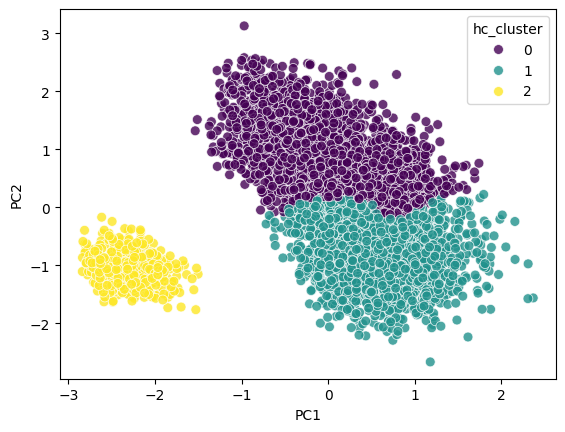

In [329]:
sns.scatterplot(x='PC1', y='PC2', hue='hc_cluster', data=df_hc, palette='viridis', s=50, alpha=0.8)

# 5. Eksperimen Model DBSCAN


In [331]:
df_dbscan = df_scaled.copy()

In [333]:
epsilon = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
min_samples = [10, 15, 20, 25]

sil_avg = []
max_value = (0, 0, 0, -1)  # Initialize max_value with a negative silhouette score

for i in range(len(epsilon)):
    for j in range(len(min_samples)):
        db = DBSCAN(min_samples=min_samples[j], eps=epsilon[i]).fit(df_dbscan)

        # Check if there are at least two clusters
        unique_labels = set(db.labels_)
        if len(unique_labels) >= 2:
            core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
            core_samples_mask[db.core_sample_indices_] = True
            labels = db.labels_

            # Number of clusters in labels, ignoring noise if present.
            n_clusters_ = len(unique_labels) - (1 if -1 in labels else 0)
            n_noise_ = list(labels).count(-1)

            silhouette_avg = silhouette_score(df_dbscan, labels)
            sil_avg.append(silhouette_avg)

            if silhouette_avg > max_value[3]:
                max_value = (epsilon[i], min_samples[j], n_clusters_, silhouette_avg)

print("epsilon =", max_value[0],
      "\nmin_samples =", max_value[1],
      "\nnumber of clusters =", max_value[2],
      "\naverage silhouette score = %.4f" % max_value[3])

epsilon = 0.6 
min_samples = 10 
number of clusters = 2 
average silhouette score = 0.5717


--- Memulai Evaluasi DBSCAN (min_samples = 10) ---

✅ Selesai! Epsilon Paling Optimal adalah: 0.6
🏆 Dengan Silhouette Score: 0.5717


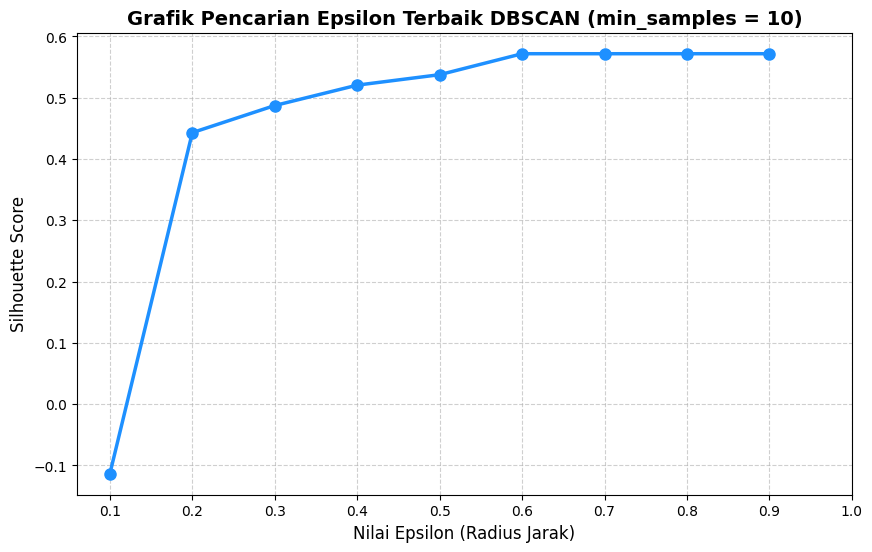

In [334]:
import matplotlib.pyplot as plt

# Parameter Anda
epsilon = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
min_samples_fixed = 10

# Siapkan list kosong untuk sumbu X (Epsilon valid) dan Sumbu Y (Skor)
eps_valid = []
sil_scores = []
max_value = (0, -1)  # (best_epsilon, best_score)

print(f"--- Memulai Evaluasi DBSCAN (min_samples = {min_samples_fixed}) ---")

for eps in epsilon:
    # Jalankan DBSCAN
    db = DBSCAN(min_samples=min_samples_fixed, eps=eps).fit(df_dbscan)
    unique_labels = set(db.labels_)
    
    # Hanya hitung Silhouette jika minimal ada 2 grup (termasuk grup 'Noise')
    if len(unique_labels) >= 2:
        labels = db.labels_
        silhouette_avg = silhouette_score(df_dbscan, labels)
        
        # Simpan koordinat X dan Y untuk grafik
        eps_valid.append(eps)
        sil_scores.append(silhouette_avg)
        
        # Catat juara tertingginya
        if silhouette_avg > max_value[1]:
            max_value = (eps, silhouette_avg)

# --- BAGIAN REPORT TEXT ---
if len(eps_valid) > 0:
    print(f"\n✅ Selesai! Epsilon Paling Optimal adalah: {max_value[0]}")
    print(f"🏆 Dengan Silhouette Score: {max_value[1]:.4f}")
else:
    print("\n⚠️ PERINGATAN: Tidak ada Epsilon yang berhasil membentuk >= 2 kluster.")

# --- BAGIAN VISUALISASI GRAFIK ---
plt.figure(figsize=(10, 6))

# Gambar garis line plot (dengan penanda titik bulat 'o')
plt.plot(eps_valid, sil_scores, marker='o', linestyle='-', color='dodgerblue', linewidth=2.5, markersize=8)

# Percantik Grafik
plt.title(f'Grafik Pencarian Epsilon Terbaik DBSCAN (min_samples = {min_samples_fixed})', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Epsilon (Radius Jarak)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(epsilon) # Paksa sumbu X menampilkan angka epsilon yang dicek persis
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [335]:
db=DBSCAN(eps=0.6, min_samples=10, metric='euclidean')

db_cluster = db.fit_predict(df_dbscan)

df_dbscan['cluster'] = db_cluster
df_dbscan.head()

,PC1,PC2,cluster
0,-0.828247,1.826930,0
1,0.406339,0.613024,0
2,-2.139614,-0.975137,1
3,-0.843371,2.177926,0
4,-2.584822,-1.103807,1


<Axes: xlabel='PC1', ylabel='PC2'>

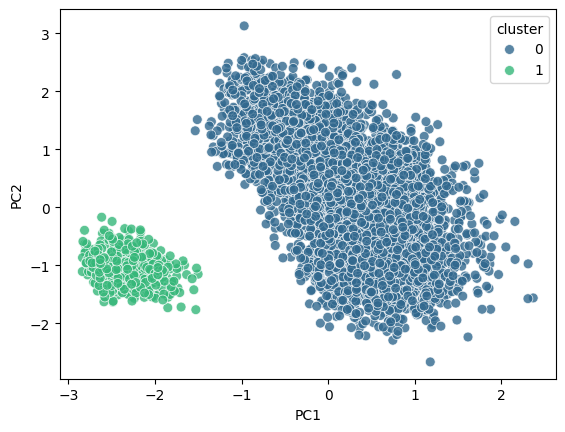

In [337]:
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_dbscan, palette='viridis', s=50, alpha=0.8)

# 6. Analisis & Kesimpulan